# Hybrid Stacking XAU/USD Analysis

Notebook nay chay pipeline du bao tin hieu giao dich XAU/USD tu du lieu parquet trong `data/raw/XAUUSD/`.

Mac dinh dung `MONTHS = 1` de smoke test nhanh. Tang len `12` hoac dat `None` neu muon chay full dataset.

## 1. Setup

Neu chay bang Pixi, mo notebook tu root repo hoac chay kernel trong environment da `pixi install`. Notebook dung `accelerate` de cau hinh runtime, `numba` qua cac helper JIT trong package, va `matplotlib` de xuat chart.

In [1]:
from pathlib import Path

from IPython.display import Image, display
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, f1_score

from hybrid_stacking.acceleration import configure_accelerator
from hybrid_stacking.backtest import backtest_signals, cost_adjusted_returns, equity_curve
from hybrid_stacking.config import (
    CV_SPLITS,
    DATA_DIR,
    EMBARGO_PCT,
    MIN_OOF_F1,
    RANDOM_STATE,
    REPORT_DIR,
    PipelineConfig,
    TradingCosts,
)
from hybrid_stacking.data import parquet_files
from hybrid_stacking.dataset import build_dataset, feature_columns, train_test_time_split
from hybrid_stacking.models import HybridStackingSignalClassifier
from hybrid_stacking.reporting import save_run_plots

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

accelerator = configure_accelerator(RANDOM_STATE)
print(f"Accelerate device: {accelerator.device} | processes: {accelerator.num_processes}")

Accelerate device: cpu | processes: 1


In [2]:
MONTHS = 24  # 1 = smoke test, 12 = default thesis run, None = full dataset
config = PipelineConfig(months=MONTHS)

files = parquet_files(DATA_DIR, config.months)
print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Parquet files: {len(files)}")
print(f"First file: {files[0].name}")
print(f"Last file: {files[-1].name}")

Data dir: /home/ultimatebrok/Downloads/thesis-compact/data/raw/XAUUSD
Parquet files: 24
First file: 2024-05.parquet
Last file: 2026-04.parquet


## 2. Build Dataset

Pipeline load tick parquet bang Polars, resample thanh nen `1h`, tao technical features, roi gan nhan triple-barrier.

In [3]:
dataset = build_dataset(config)
train, test = train_test_time_split(dataset)
features = feature_columns(dataset)

print(f"Rows: {len(dataset):,}")
print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Features: {len(features)}")
print(f"Fractional d*: {dataset.attrs.get('fractional_d', 'n/a')}")
dataset.head()

Rows: 11,623
Train: 9,298 | Test: 2,325
Features: 21
Fractional d*: 0.5


,open,high,low,close,volume,spread,close_denoised,close_fracdiff,return_1,return_4,return_12,ema_12,ema_26,macd,macd_signal,rsi_14,stoch_14,ao,atr_14,bb_width,bb_position,volatility_24,hour,dayofweek,label,event_end
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-05-13 09:00:00,2343.3450,2344.3765,2339.1885,2340.2485,2.800580,0.353484,2346.013469,91.127429,-0.001306,-0.005287,-0.008672,2352.178487,2354.311365,-2.132879,1.246855,12.432388,3.740098,-11.473137,4.945321,0.014017,-1.115123,0.001407,9,0,1,202
2024-05-13 10:00:00,2340.2635,2344.1900,2339.3700,2343.3765,2.395390,0.359110,2344.415188,90.866683,0.001337,-0.002691,-0.007706,2350.824335,2353.501375,-2.677040,0.462076,21.587594,16.166763,-13.599213,4.914857,0.014681,-0.814354,0.001412,10,0,-1,205
2024-05-13 11:00:00,2343.3650,2346.6900,2338.5000,2344.6600,3.453395,0.350956,2342.950725,90.704186,0.000548,-0.001716,-0.006701,2349.875976,2352.846459,-2.970483,-0.224436,26.291704,23.651373,-15.131721,5.120679,0.015392,-0.661780,0.001396,11,0,-1,205
2024-05-13 12:00:00,2344.5145,2349.8615,2343.7100,2347.1650,4.759570,0.365794,2341.661330,90.651448,0.001068,0.001645,-0.007170,2349.458902,2352.425610,-2.966707,-0.772890,29.715653,33.269342,-15.425968,5.264000,0.015429,-0.473769,0.001428,12,0,-1,203
2024-05-13 13:00:00,2347.1800,2349.4800,2340.4300,2344.1650,6.460980,0.370207,2340.575563,90.704562,-0.001278,0.001674,-0.006380,2348.644456,2351.813713,-3.169257,-1.252163,28.205711,21.750816,-15.511585,5.707929,0.015169,-0.582268,0.001325,13,0,-1,205


In [4]:
label_summary = (
    dataset["label"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("share")
    .to_frame()
)
label_summary["count"] = dataset["label"].value_counts().sort_index()
label_summary

,share,count
label,,
-1,0.524047,6091
0,0.070636,821
1,0.405317,4711


In [5]:
dataset[["open", "high", "low", "close", "volume", "spread", "label"]].describe().T

,count,mean,std,min,25%,50%,75%,max
open,11623.0,3372.288480,855.231430,2288.320000,2645.857500,3291.250000,4069.556000,5562.753000
high,11623.0,3378.576800,858.963532,2294.435000,2648.875250,3296.630000,4078.767500,5598.260000
low,11623.0,3365.654308,850.971395,2286.836500,2642.437500,3285.276500,4059.838250,5554.825000
close,11623.0,3372.476597,855.242667,2288.400000,2645.867500,3291.350000,4069.651750,5562.625000
volume,11623.0,4.820400,3.116903,0.076350,2.648685,4.108390,6.173635,28.827880
spread,11623.0,0.584168,0.230046,0.276994,0.415490,0.555227,0.667685,7.605942
label,11623.0,-0.118730,0.956737,-1.000000,-1.000000,-1.000000,1.000000,1.000000


## 3. Train Hybrid Stacking Model

Model dung purged/embargoed time-series CV, smart-filter cac base model theo OOF macro F1, roi train meta Logistic Regression.

In [6]:
model = HybridStackingSignalClassifier(
    n_splits=CV_SPLITS,
    embargo_pct=EMBARGO_PCT,
    min_oof_f1=MIN_OOF_F1,
    random_state=RANDOM_STATE,
)
model.fit(train[features], train["label"], train["event_end"])

pd.DataFrame(
    {
        "oof_macro_f1": model.oof_scores_,
        "status": {name: "ACTIVE" if name in model.active_model_names_ else "FILTERED" for name in model.oof_scores_},
    }
).sort_values("oof_macro_f1", ascending=False)

,oof_macro_f1,status
lightgbm,0.395159,ACTIVE
random_forest,0.379694,ACTIVE
svc_rbf,0.378216,ACTIVE
extra_trees,0.360408,ACTIVE
xgboost,0.328111,FILTERED


## 4. Evaluate Holdout


In [7]:
predictions = model.predict(test[features])

print(f"Accuracy: {accuracy_score(test['label'], predictions):.4f}")
print(f"F1 macro: {f1_score(test['label'], predictions, average='macro', zero_division=0):.4f}")
print(classification_report(test["label"], predictions, zero_division=0))

Accuracy: 0.5110
F1 macro: 0.3934
              precision    recall  f1-score   support

          -1       0.61      0.69      0.65      1261
           0       0.10      0.19      0.13       204
           1       0.52      0.32      0.40       860

    accuracy                           0.51      2325
   macro avg       0.41      0.40      0.39      2325
weighted avg       0.53      0.51      0.51      2325



In [8]:
pd.crosstab(
    test["label"],
    pd.Series(predictions, index=test.index, name="prediction"),
    rownames=["actual"],
    normalize="index",
).round(3)

prediction,-1,0,1
actual,,,
-1,0.693,0.137,0.170
0,0.613,0.186,0.201
1,0.503,0.176,0.321


## 5. Backtest

Backtest don gian: dung prediction lam position cho return nen tiep theo, tru spread va slippage.

In [9]:
metrics = backtest_signals(test, predictions)
pd.Series(metrics, name="value").to_frame()

,value
trades,1963.000000
total_return,0.600895
sharpe,4.179930
max_drawdown,-0.215475
profit_factor,1.208811


In [10]:
strategy_returns = cost_adjusted_returns(test, predictions, TradingCosts())
equity = equity_curve(strategy_returns, test.index).rename("equity")
equity.tail()

timestamp
2026-04-30 06:00:00    1.616134
2026-04-30 07:00:00    1.609675
2026-04-30 08:00:00    1.606365
2026-04-30 09:00:00    1.601111
2026-04-30 10:00:00    1.600895
Name: equity, dtype: float64

## 6. Export Results And Plots

Cell nay luu prediction, equity curve va Matplotlib plots de dung cho bao cao.

Saved 2,325 rows and plots to /home/ultimatebrok/Downloads/thesis-compact/reports


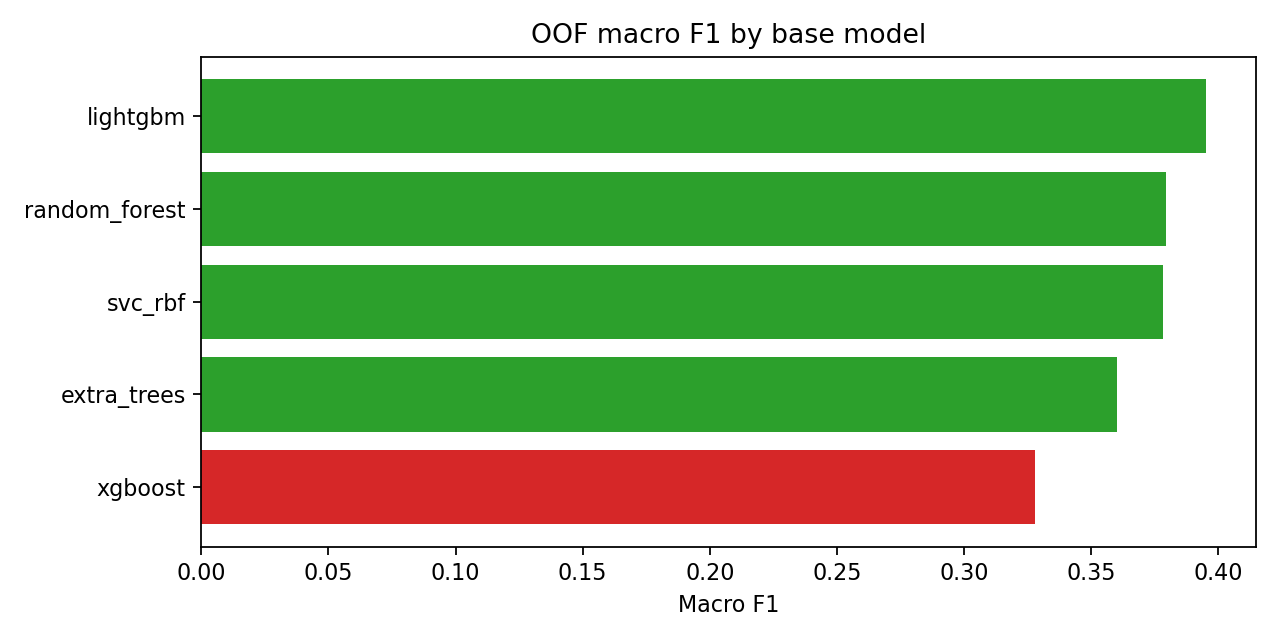

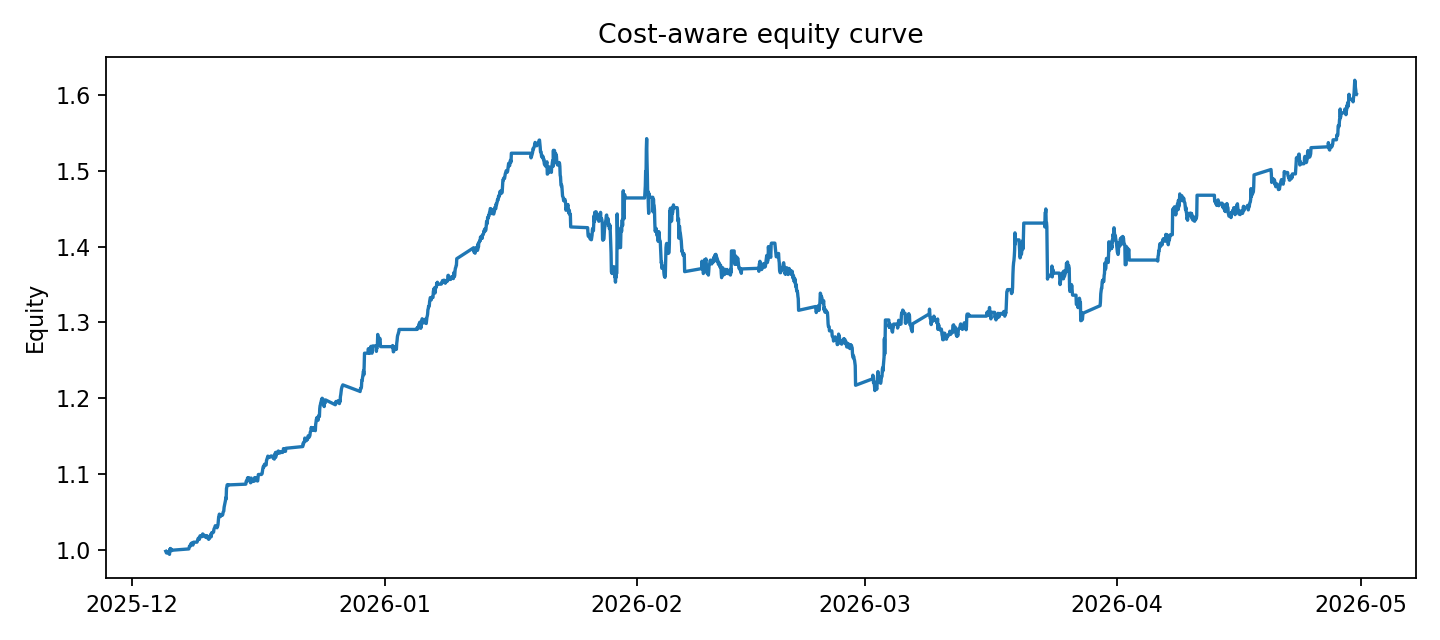

In [11]:
output_dir = REPORT_DIR
output_dir.mkdir(exist_ok=True)

results = test[["close", "spread", "label"]].copy()
results["prediction"] = predictions
results["strategy_return"] = strategy_returns
results["equity"] = equity
results.to_csv(output_dir / "hybrid_stacking_predictions.csv")

pd.Series(metrics).to_csv(output_dir / "hybrid_stacking_backtest_metrics.csv")
save_run_plots(model, equity, output_dir)

print(f"Saved {len(results):,} rows and plots to {output_dir.resolve()}")
display(Image(filename=str(output_dir / "model_oof_f1.png")))
display(Image(filename=str(output_dir / "equity_curve.png")))